In [20]:
import matplotlib.pyplot as plt
from PIL import Image
from configs.loader import cfg
import torch
import numpy as np
from models.models import YOLODetector, SAM2Predictor

def run_yolo_sam(rgb, detection_model, sam_predictor, cfg):
    """
    INPUT:
        rgb  : np.ndarray (H, W, 3), uint8, rotated/upscaled already

    RETURNS:
        masks: list of (H, W) boolean arrays
        class_ids:  (N,)
        confidences: (N,)
        bboxes: (N, 4) float32
    """

    # =========================================================
    # Step 1 — YOLO DETECTION
    # =========================================================
    bboxes, class_ids, confs = detection_model(rgb)

    # No detection → return empty outputs
    if len(bboxes) == 0:
        return [], np.array([]), np.array([]), np.empty((0, 4), dtype=np.float32)

    # ultralytics SAM-compatible tensor format
    bboxes_tensor = torch.tensor(bboxes, dtype=torch.float32, device=cfg.device)

    # =========================================================
    # Step 2 — SAM MASKING
    # =========================================================
    masks_np = sam_predictor(rgb, bboxes_tensor)

    if masks_np is None or len(masks_np) == 0:
        return [], class_ids, confs, bboxes
    if masks_np.ndim == 4:
        masks_np = masks_np[:, 0]

    masks = [m.astype(bool) for m in masks_np]

    return masks, class_ids, confs, bboxes



In [21]:
yolo = YOLODetector(cfg)
sam = SAM2Predictor(cfg)

[YOLO Detector] Loading src/models/weights/yolov8l-world.pt
[SAM2] Loading src/models/weights/sam2.1_b.pt → cuda


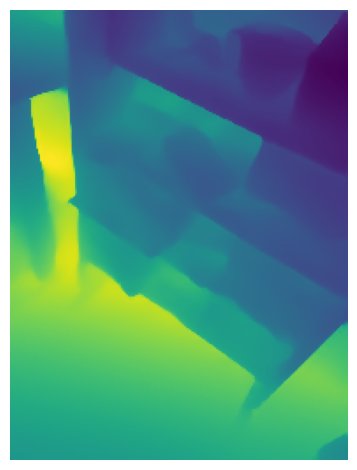

In [22]:
image = Image.open(f'../data/iphone/3578aa5730/depth/{935:06d}.png')
image = image.rotate(-90, expand=True)
plt.imshow(image)
plt.axis('off')
plt.tight_layout()
plt.show()

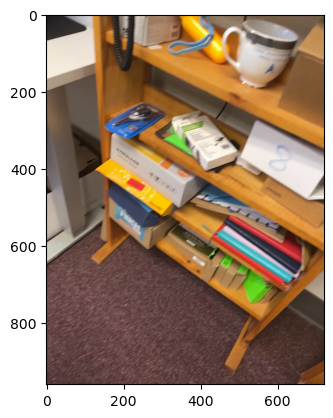

In [23]:
rgb = np.array(Image.open(f'../data/iphone/3578aa5730/rgb_frames/{935:06d}.png'))
plt.imshow(rgb)
plt.show()

In [24]:
masks, class_ids, confs, bboxes = run_yolo_sam(rgb, yolo, sam, cfg)

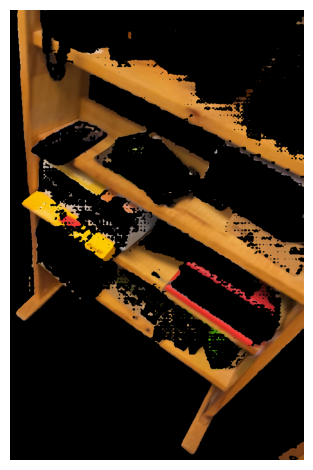

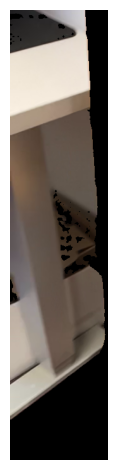

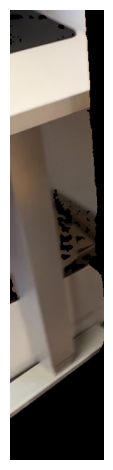

In [39]:
for mask, bbox in zip(masks, bboxes):
    rgb_mask = np.stack([mask, mask, mask], -1)
    xmin, ymin, xmax, ymax = bbox
    rgb_masked = rgb * rgb_mask
    cropped = rgb_masked[int(ymin):int(ymax), int(xmin):int(xmax)]
    plt.imshow(cropped)
    plt.axis('off')
    plt.tight_layout()
    plt.show()